In [ ]:
# Author: Rebecca Yang
# Creation date: March 6th, 20206
# Description: conducts EDA on financial news data on NVDA 

import feedparser
import pandas as pd
from datetime import datetime, timedelta
from tqdm import tqdm
import time
import yfinance as yf

start_date = datetime(2020, 1, 1)  # first day to collect
end_date = datetime(2026, 3, 1)    # last day
delta = timedelta(days=30)         # batch = 30 days

all_articles = []

#loop over date ranges
current_start = start_date
while current_start < end_date:
    current_end = min(current_start + delta, end_date)
    
    #format for Google News RSS
    rss_url = f"https://news.google.com/rss/search?q=NVDA+OR+NVIDIA+after:{current_start.strftime('%Y-%m-%d')}+before:{current_end.strftime('%Y-%m-%d')}&hl=en-US&gl=US&ceid=US:en"
    
    feed = feedparser.parse(rss_url)
    
    for entry in feed.entries:
        all_articles.append({
            "title": entry.title,
            "link": entry.link,
            "published": entry.published
        })
    
    current_start += delta
    time.sleep(0.5)
print(f"Total articles collected: {len(all_articles)}")

#convert to df
df = pd.DataFrame(all_articles)
df["date"] = pd.to_datetime(df["published"], errors='coerce')
df = df.dropna(subset=["date"])
df = df.drop_duplicates(subset=["title"])

#merge with NVDA stock price
ticker = yf.Ticker("NVDA")
stock_data = yf.download("NVDA", start=df["date"].min().date(), end=df["date"].max().date())
stock_data = stock_data.reset_index()[["Date", "Close"]]
stock_data.rename(columns={"Date": "date", "Close": "close_price"}, inplace=True)

df["date"] = pd.to_datetime(df["date"]).dt.date
stock_data["date"] = pd.to_datetime(stock_data["date"]).dt.date
stock_data.columns = stock_data.columns.get_level_values(0)
df_merged = pd.merge(df, stock_data, on="date", how="left")
df_merged = df_merged.sort_values(by="date")
df_merged["close_price"] = df_merged["close_price"].ffill()

#save data
df_merged.to_csv("nvidia_news_large_free.csv", index=False)
print("Saved dataset as nvidia_news_large_free.csv")

[*********************100%***********************]  1 of 1 completed

Total articles collected: 7600
Saved dataset as nvidia_news_large_free.csv


In [65]:
print(df_merged)
df_merged["close_price"].isna().sum()

                                                  title  \
44    NVIDIA Ampere GPU: 50% faster than Turing at H...   
52    New Studio Driver Now Available, Optimizes Per...   
78    Introducing GeForce GTX 1660 and 1650 SUPER GP...   
0     NVIDIA Announces New G-SYNC Esports Displays -...   
2     New G-SYNC Esports Displays at CES 2020 | GeFo...   
...                                                 ...   
7337  Building Telco Reasoning Models for Autonomous...   
7395  (NVDA) Equity Trading Insights (NVDA:CA) - Sto...   
7335  5 New Digital Twin Products Developers Can Use...   
7331  Nvidia Forms Alliance to Make Sure 6G Networks...   
7419  NVIDIA and Global Telecom Leaders Commit to Bu...   

                                                   link  \
44    https://news.google.com/rss/articles/CBMimAFBV...   
52    https://news.google.com/rss/articles/CBMifkFVX...   
78    https://news.google.com/rss/articles/CBMiiwFBV...   
0     https://news.google.com/rss/articles/CBMihAFBV...

0

In [68]:
print("Total articles:", len(df))
print("Date range:", df['date'].min(), "to", df['date'].max())
print("Unique sources:", df['link'].nunique())

Total articles: 7420
Date range: 2020-01-02 00:00:00 to 2026-03-01 00:00:00
Unique sources: 7420


[*********************100%***********************]  1 of 1 completed


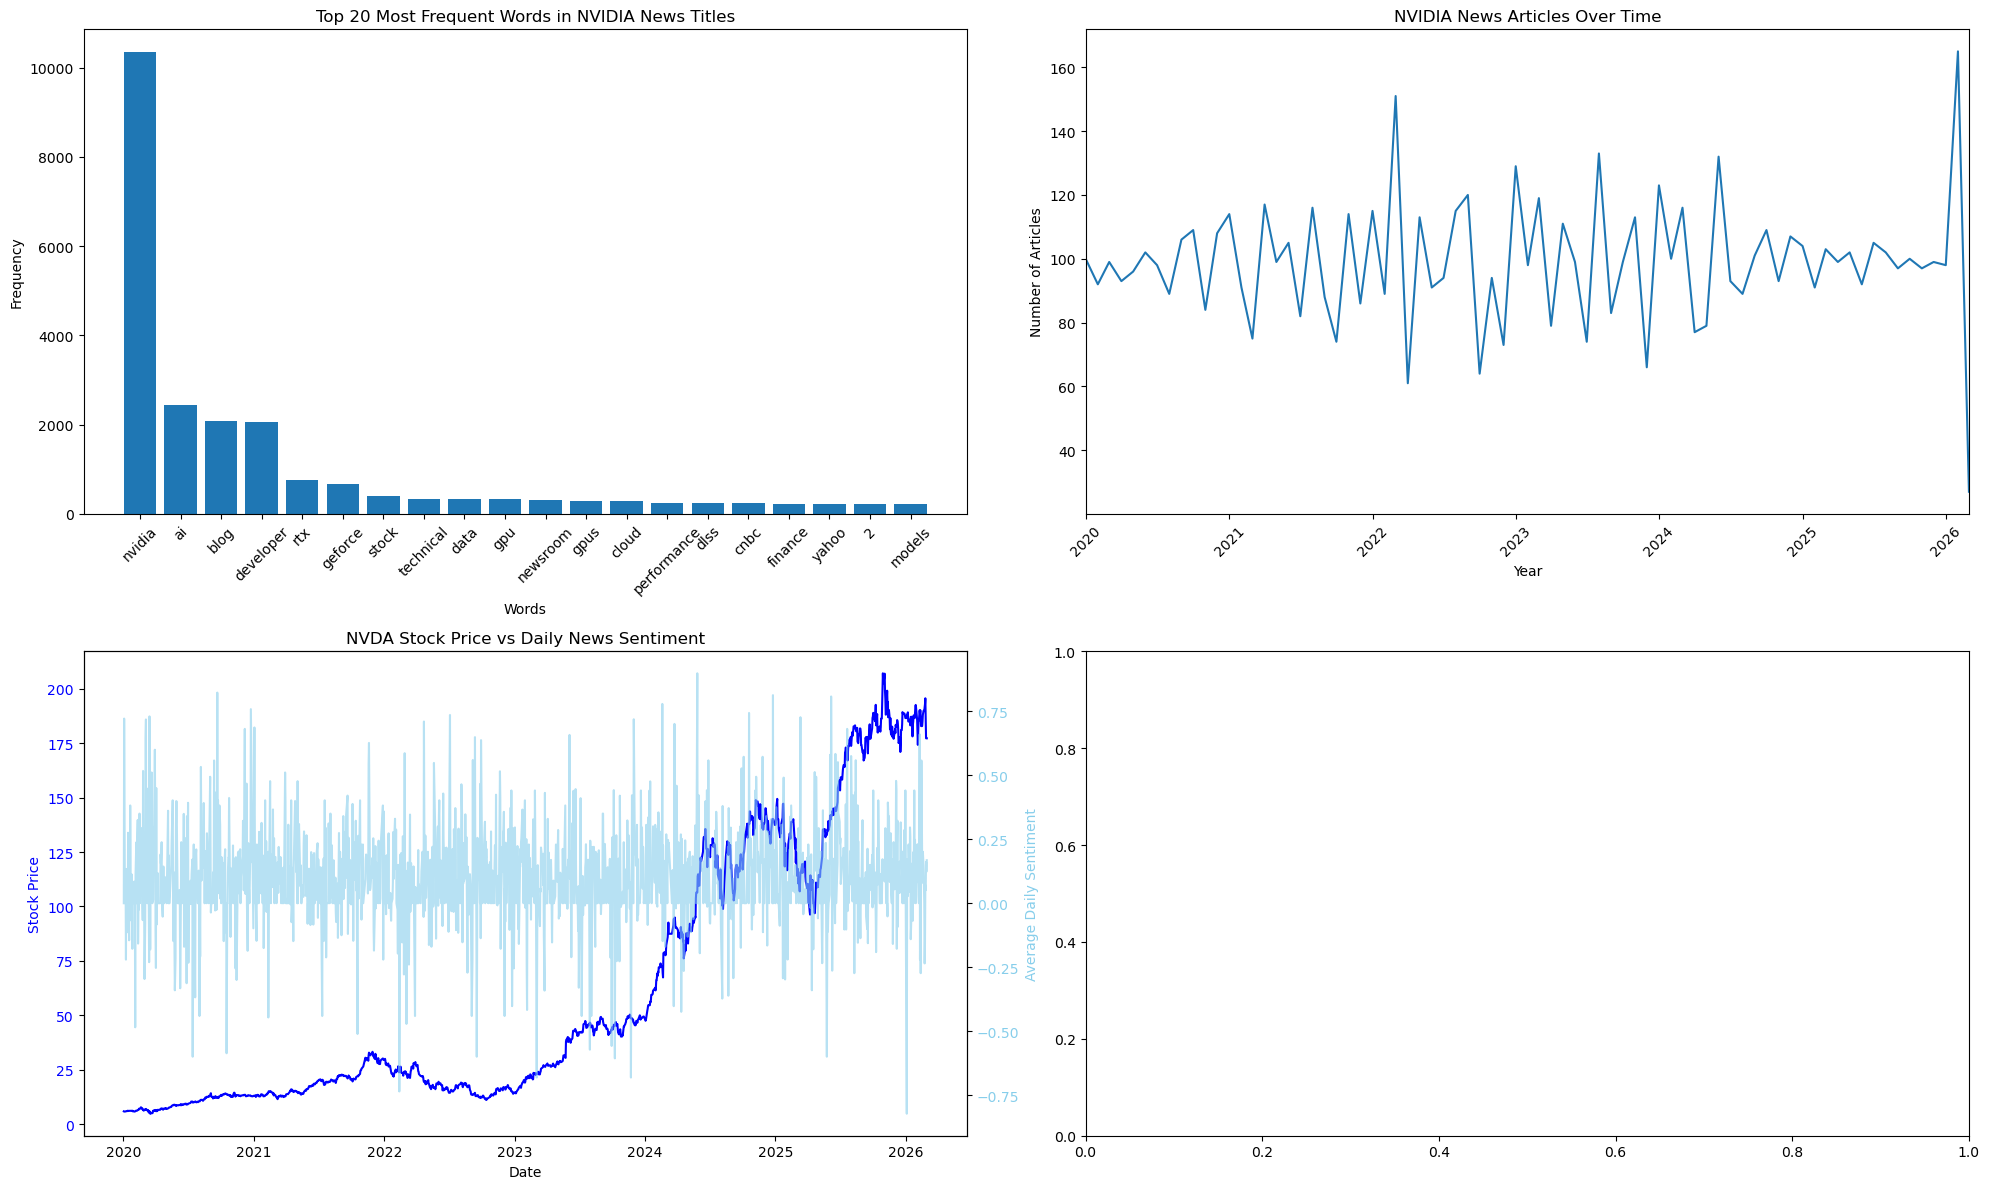

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import yfinance as yf



#convert date to datetime
df['date'] = pd.to_datetime(df['date'])

#find top 20 words
text = " ".join(df['title'].dropna()).lower()
words = re.findall(r'\b\w+\b', text)

stopwords = set([ #list of words to not include
    "the","and","for","to","of","in","on","with","at","as","a","an",
    "is","new","now","how","s","from","using","by"
])
words = [w for w in words if w not in stopwords]

word_counts = Counter(words)
top_words = word_counts.most_common(20)
word_labels = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

#find monthly news volume in the last year
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()
monthly_counts = df.groupby('month').size()


last_month = monthly_counts.index.max()
first_month = monthly_counts.index.min()
monthly_counts_last12 = monthly_counts[(monthly_counts.index >= first_month)]

#daily sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['title'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
daily_sentiment = df.groupby('date')['sentiment_score'].mean().reset_index()

#daily stock price
stock_data = yf.download(
    "NVDA",
    start=daily_sentiment['date'].min(),
    end=daily_sentiment['date'].max()
).reset_index()

stock_data = stock_data[['Date','Close']]
stock_data.columns = ['date','close_price']
stock_data['date'] = pd.to_datetime(stock_data['date'])

#merge daily sentiment with stock price
daily_plot = pd.merge(daily_sentiment, stock_data, on='date', how='left')
daily_plot['close_price'] = daily_plot['close_price'].ffill()  #forward fill missing prices

#plot
fig, axes = plt.subplots(2,2, figsize=(20,12))

#top words
axes[0,0].bar(word_labels, counts)
axes[0,0].set_title("Top 20 Most Frequent Words in NVIDIA News Titles")
axes[0,0].set_xlabel("Words")
axes[0,0].set_ylabel("Frequency")
axes[0,0].tick_params(axis='x', rotation=45)

#news volume last 12 months
axes[0,1].plot(monthly_counts.index, monthly_counts.values)
axes[0,1].set_title("NVIDIA News Articles Over Time")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Number of Articles")
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_xlim(first_month, last_month)

#daily sentiment vs NVDA stock price
ax3 = axes[1,0]
ax3.plot(daily_plot['date'], daily_plot['close_price'], color='blue', label='NVDA Price')
ax3.set_xlabel("Date")
ax3.set_ylabel("Stock Price", color='blue')
ax3.tick_params(axis='y', labelcolor='blue')

ax4 = ax3.twinx()
ax4.plot(daily_plot['date'], daily_plot['sentiment_score'], color='skyblue', alpha=0.6, label='Daily Sentiment')
ax4.set_ylabel("Average Daily Sentiment", color='skyblue')
ax4.tick_params(axis='y', labelcolor='skyblue')

axes[1,0].set_title("NVDA Stock Price vs Daily News Sentiment")

plt.tight_layout()
plt.show()